In [1]:
import os

# Tumcha Kaggle Username ani API Key ithhe taka
os.environ['KAGGLE_USERNAME'] = "kusumithnimsara"
os.environ['KAGGLE_KEY'] = "KGAT_90d2d83900db481e19bcc4dafb609026"

# Kaggle dataset download kara
!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification

# ZIP file extract kara
!unzip -q eye-diseases-classification.zip -d dataset/

Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
100% 736M/736M [00:04<00:00, 159MB/s]



In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# Image dimensions and Batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation & Normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2 # 80% Training, 20% Validation
)

# Train Data Generator
train_generator = train_datagen.flow_from_directory(
    'dataset/dataset',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Validation Data Generator
val_generator = train_datagen.flow_from_directory(
    'dataset/dataset',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 3376 images belonging to 4 classes.
Found 841 images belonging to 4 classes.


In [3]:
# Base DenseNet121 Model with pre-trained ImageNet weights
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers initially
base_model.trainable = False

# Attach classification layers
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,028 (27.87 MB)

 Trainable params: 265,476 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [4]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_densenet121.h5', monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - accuracy: 0.7058 - loss: 0.7178

106/106 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.7894 - loss: 0.5376 - val_accuracy: 0.5125 - val_loss: 1.0952
Epoch 2/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.8568 - loss: 0.3932

106/106 ━━━━━━━━━━━━━━━━━━━━ 77s 724ms/step - accuracy: 0.8643 - loss: 0.3711 - val_accuracy: 0.7170 - val_loss: 0.6913
Epoch 3/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 76s 718ms/step - accuracy: 0.8774 - loss: 0.3272 - val_accuracy: 0.6920 - val_loss: 0.7628
Epoch 4/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.8971 - loss: 0.2985

106/106 ━━━━━━━━━━━━━━━━━━━━ 78s 732ms/step - accuracy: 0.8898 - loss: 0.3095 - val_accuracy: 0.7229 - val_loss: 0.6782
Epoch 5/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.8973 - loss: 0.2858

106/106 ━━━━━━━━━━━━━━━━━━━━ 77s 723ms/step - accuracy: 0.8928 - loss: 0.2966 - val_accuracy: 0.7325 - val_loss: 0.6842
Epoch 6/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 75s 709ms/step - accuracy: 0.9020 - loss: 0.2635 - val_accuracy: 0.7229 - val_loss: 0.6836
Epoch 7/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.9175 - loss: 0.2152

106/106 ━━━━━━━━━━━━━━━━━━━━ 76s 717ms/step - accuracy: 0.9023 - loss: 0.2556 - val_accuracy: 0.7705 - val_loss: 0.5670
Epoch 8/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 76s 712ms/step - accuracy: 0.9052 - loss: 0.2463 - val_accuracy: 0.7515 - val_loss: 0.6066
Epoch 9/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 75s 710ms/step - accuracy: 0.9114 - loss: 0.2355 - val_accuracy: 0.7039 - val_loss: 0.7447
Epoch 10/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 82s 711ms/step - accuracy: 0.9108 - loss: 0.2362 - val_accuracy: 0.7634 - val_loss: 0.5899
Epoch 11/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 76s 718ms/step - accuracy: 0.9227 - loss: 0.2116 - val_accuracy: 0.7574 - val_loss: 0.6395
Epoch 12/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 76s 714ms/step - accuracy: 0.9245 - loss: 0.2109 - val_accuracy: 0.7467 - val_loss: 0.6325


In [5]:
# Base model trainable karanna
base_model.trainable = True

# Lower Learning Rate ekak bawitha karanna
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Re-train for fine-tuning
history_finetune = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.8092 - loss: 0.5071 - val_accuracy: 0.6671 - val_loss: 1.1107
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 83s 785ms/step - accuracy: 0.8632 - loss: 0.3662 - val_accuracy: 0.6516 - val_loss: 1.0002
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 83s 787ms/step - accuracy: 0.8809 - loss: 0.3230 - val_accuracy: 0.7265 - val_loss: 0.7214
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.8918 - loss: 0.2863

106/106 ━━━━━━━━━━━━━━━━━━━━ 86s 805ms/step - accuracy: 0.9008 - loss: 0.2665 - val_accuracy: 0.7824 - val_loss: 0.5566
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.8985 - loss: 0.2631

106/106 ━━━━━━━━━━━━━━━━━━━━ 86s 812ms/step - accuracy: 0.9076 - loss: 0.2406 - val_accuracy: 0.7848 - val_loss: 0.5201
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 83s 786ms/step - accuracy: 0.9203 - loss: 0.2134 - val_accuracy: 0.7729 - val_loss: 0.5681
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 85s 799ms/step - accuracy: 0.9348 - loss: 0.1872 - val_accuracy: 0.7824 - val_loss: 0.5708
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 83s 787ms/step - accuracy: 0.9328 - loss: 0.1839 - val_accuracy: 0.7646 - val_loss: 0.5461
Epoch 9/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 85s 797ms/step - accuracy: 0.9336 - loss: 0.1783 - val_accuracy: 0.7765 - val_loss: 0.5510
Epoch 10/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 83s 783ms/step - accuracy: 0.9428 - loss: 0.1586 - val_accuracy: 0.7491 - val_loss: 0.6551


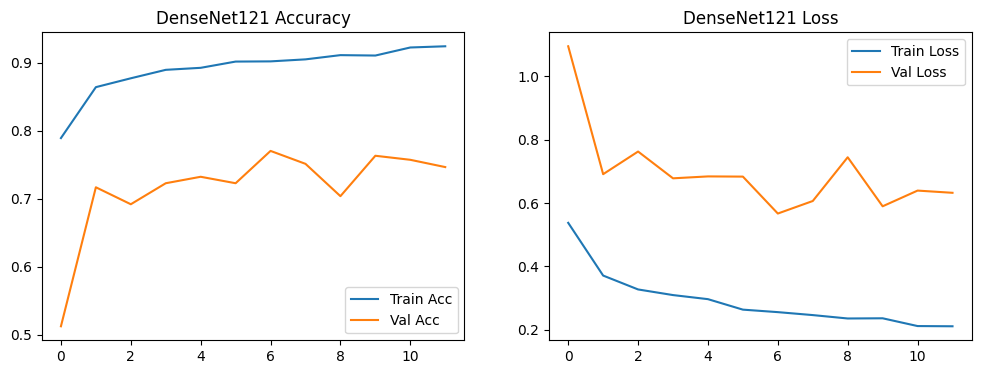

In [6]:
# Plot Accuracy and Loss graphs
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('DenseNet121 Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('DenseNet121 Loss')
plt.legend()
plt.show()